## Training Setup 

##### Load and split

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder, label_binarize
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    auc,
)
from IPython.display import display


In [2]:
DATA_DIR = Path.cwd().resolve()

acc_data = np.load(DATA_DIR / "acc_features_full.npz", allow_pickle=True)
x_acc = acc_data["features"]
y_acc_raw = acc_data["labels"]

gyro_data = np.load(DATA_DIR / "gyro_features_full.npz", allow_pickle=True)
x_gyro = gyro_data["features"]
y_gyro_raw = gyro_data["labels"]

label_encoder = LabelEncoder()
label_encoder.fit(np.concatenate([np.asarray(y_acc_raw).astype(str), np.asarray(y_gyro_raw).astype(str)]))
y_acc = label_encoder.transform(np.asarray(y_acc_raw).astype(str))
y_gyro = label_encoder.transform(np.asarray(y_gyro_raw).astype(str))
class_names = list(label_encoder.classes_)

print('Accelerometer feature shape:', x_acc.shape)
print('Gyroscope feature shape:', x_gyro.shape)
print('Classes:', class_names)


Accelerometer feature shape: (112787, 64)
Gyroscope feature shape: (120627, 64)
Classes: [np.str_('0'), np.str_('1'), np.str_('2'), np.str_('3'), np.str_('4'), np.str_('5')]


In [3]:
# Stratified splits: 70% train, 10% validation, 20% test
x_acc_train, x_acc_test, y_acc_train, y_acc_test = train_test_split(
    x_acc, y_acc, test_size=0.2, random_state=42, stratify=y_acc
)
x_acc_train, x_acc_val, y_acc_train, y_acc_val = train_test_split(
    x_acc_train, y_acc_train, test_size=0.125, random_state=42, stratify=y_acc_train
)

x_gyro_train, x_gyro_test, y_gyro_train, y_gyro_test = train_test_split(
    x_gyro, y_gyro, test_size=0.2, random_state=42, stratify=y_gyro
)
x_gyro_train, x_gyro_val, y_gyro_train, y_gyro_val = train_test_split(
    x_gyro_train, y_gyro_train, test_size=0.125, random_state=42, stratify=y_gyro_train
)

print('Accelerometer splits:', x_acc_train.shape, x_acc_val.shape, x_acc_test.shape)
print('Gyroscope splits:', x_gyro_train.shape, x_gyro_val.shape, x_gyro_test.shape)


Accelerometer splits: (78950, 64) (11279, 64) (22558, 64)
Gyroscope splits: (84438, 64) (12063, 64) (24126, 64)


##### Scale the features

In [4]:
# Scale the features for training 
scaler_acc = StandardScaler()
x_acc_train_scaled = scaler_acc.fit_transform(x_acc_train)
x_acc_val_scaled = scaler_acc.transform(x_acc_val)
x_acc_test_scaled = scaler_acc.transform(x_acc_test)

scaler_gyro = StandardScaler()
x_gyro_train_scaled = scaler_gyro.fit_transform(x_gyro_train)
x_gyro_val_scaled = scaler_gyro.transform(x_gyro_val)
x_gyro_test_scaled = scaler_gyro.transform(x_gyro_test)

print('Scaled accelerometer shape:', x_acc_train_scaled.shape)
print('Scaled gyroscope shape:', x_gyro_train_scaled.shape)


Scaled accelerometer shape: (78950, 64)
Scaled gyroscope shape: (84438, 64)


# Classification Models

### Accelerometer

In [5]:
def get_models():
    return {
        'Logistic Regression': LogisticRegression(max_iter=2000),
        'SVM': SVC(kernel='rbf', probability=True, random_state=42),
        'Random Forest': RandomForestClassifier(n_estimators=200, random_state=42),
        'Naive Bayes': GaussianNB(),
        'KNN': KNeighborsClassifier(n_neighbors=5),
    }

def evaluate_models(X_train, y_train, X_val, y_val, X_test, y_test, sensor_name):
    rows = []
    fitted_models = {}
    for name, model in get_models().items():
        model.fit(X_train, y_train)
        fitted_models[name] = model
        for split_name, X_split, y_split in [('train', X_train, y_train), ('val', X_val, y_val), ('test', X_test, y_test)]:
            pred = model.predict(X_split)
            acc = accuracy_score(y_split, pred)
            precision, recall, f1, _ = precision_recall_fscore_support(y_split, pred, average='macro', zero_division=0)
            rows.append({
                'sensor': sensor_name,
                'model': name,
                'split': split_name,
                'accuracy': acc,
                'precision': precision,
                'recall': recall,
                'f1': f1,
            })
        print(f'\n=== {sensor_name}: {name} ===')
        print(classification_report(y_test, model.predict(X_test), zero_division=0, target_names=class_names))
    return fitted_models, pd.DataFrame(rows)

In [6]:
def plot_split_scores(results_df, sensor_name):
    summary = results_df.groupby(['model', 'split'])[['accuracy', 'precision', 'recall', 'f1']].mean().reset_index()
    fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharex=True)
    metrics = ['accuracy', 'precision', 'recall', 'f1']
    for ax, metric in zip(axes.ravel(), metrics):
        pivot = summary.pivot(index='model', columns='split', values=metric)
        pivot[['train', 'val', 'test']].plot(kind='bar', ax=ax)
        ax.set_title(f'{sensor_name} - {metric.capitalize()}')
        ax.set_ylabel(metric.capitalize())
        ax.set_xlabel('Model')
        ax.legend(title='Split')
    plt.tight_layout()
    plt.show()

def plot_confusion_matrices(fitted_models, X_test, y_test, sensor_name, top_n=3):
    test_rows = []
    for name, model in fitted_models.items():
        pred = model.predict(X_test)
        precision, recall, f1, _ = precision_recall_fscore_support(y_test, pred, average='macro', zero_division=0)
        test_rows.append({'model': name, 'precision': precision, 'recall': recall, 'f1': f1})
    test_df = pd.DataFrame(test_rows).sort_values('f1', ascending=False).head(top_n)
    for name in test_df['model']:
        pred = fitted_models[name].predict(X_test)
        disp = ConfusionMatrixDisplay.from_predictions(y_test, pred, display_labels=class_names, xticks_rotation=45, cmap='Blues')
        disp.ax_.set_title(f'{sensor_name} - {name} Confusion Matrix')
        plt.tight_layout()
        plt.show()
    return test_df

def plot_multiclass_roc(fitted_models, X_test, y_test, sensor_name, top_n=3):
    test_rows = []
    for name, model in fitted_models.items():
        pred = model.predict(X_test)
        precision, recall, f1, _ = precision_recall_fscore_support(y_test, pred, average='macro', zero_division=0)
        test_rows.append({'model': name, 'precision': precision, 'recall': recall, 'f1': f1})
    test_df = pd.DataFrame(test_rows).sort_values('f1', ascending=False).head(top_n)
    y_bin = label_binarize(y_test, classes=np.arange(len(class_names)))
    plt.figure(figsize=(10, 8))
    for name in test_df['model']:
        model = fitted_models[name]
        if hasattr(model, 'predict_proba'):
            scores = model.predict_proba(X_test)
        else:
            scores = model.decision_function(X_test)
            if scores.ndim == 1:
                scores = np.column_stack([1 - scores, scores])
        fpr, tpr, _ = roc_curve(y_bin.ravel(), scores.ravel())
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, lw=2, label=f'{name} (AUC = {roc_auc:.3f})')
    plt.plot([0, 1], [0, 1], 'k--', lw=1)
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'{sensor_name} - ROC Curves')
    plt.legend(loc='lower right')
    plt.tight_layout()
    plt.show()


=== Accelerometer: Logistic Regression ===
              precision    recall  f1-score   support

           0       0.92      0.93      0.93      3749
           1       0.98      0.99      0.98      3932
           2       0.87      0.85      0.86      3255
           3       0.87      0.88      0.88      3584
           4       0.97      0.95      0.96      3673
           5       0.93      0.93      0.93      4365

    accuracy                           0.93     22558
   macro avg       0.92      0.92      0.92     22558
weighted avg       0.93      0.93      0.93     22558


=== Accelerometer: SVM ===
              precision    recall  f1-score   support

           0       0.93      0.95      0.94      3749
           1       0.98      0.99      0.99      3932
           2       0.89      0.88      0.88      3255
           3       0.88      0.91      0.89      3584
           4       0.98      0.96      0.97      3673
           5       0.96      0.93      0.94      4365

    a

,sensor,model,split,accuracy,precision,recall,f1
0,Accelerometer,Logistic Regression,train,0.928296,0.926269,0.925802,0.925950
1,Accelerometer,Logistic Regression,val,0.926944,0.924946,0.924656,0.924713
2,Accelerometer,Logistic Regression,test,0.925348,0.923208,0.923019,0.923075
3,Accelerometer,SVM,train,0.943927,0.942414,0.942140,0.942121
4,Accelerometer,SVM,val,0.938824,0.937278,0.937234,0.937046
5,Accelerometer,SVM,test,0.937140,0.935398,0.935613,0.935378
6,Accelerometer,Random Forest,train,1.000000,1.000000,1.000000,1.000000
7,Accelerometer,Random Forest,val,0.933061,0.931551,0.930997,0.930994
8,Accelerometer,Random Forest,test,0.929293,0.927487,0.927294,0.927277
9,Accelerometer,Naive Bayes,train,0.795833,0.798942,0.787156,0.782921


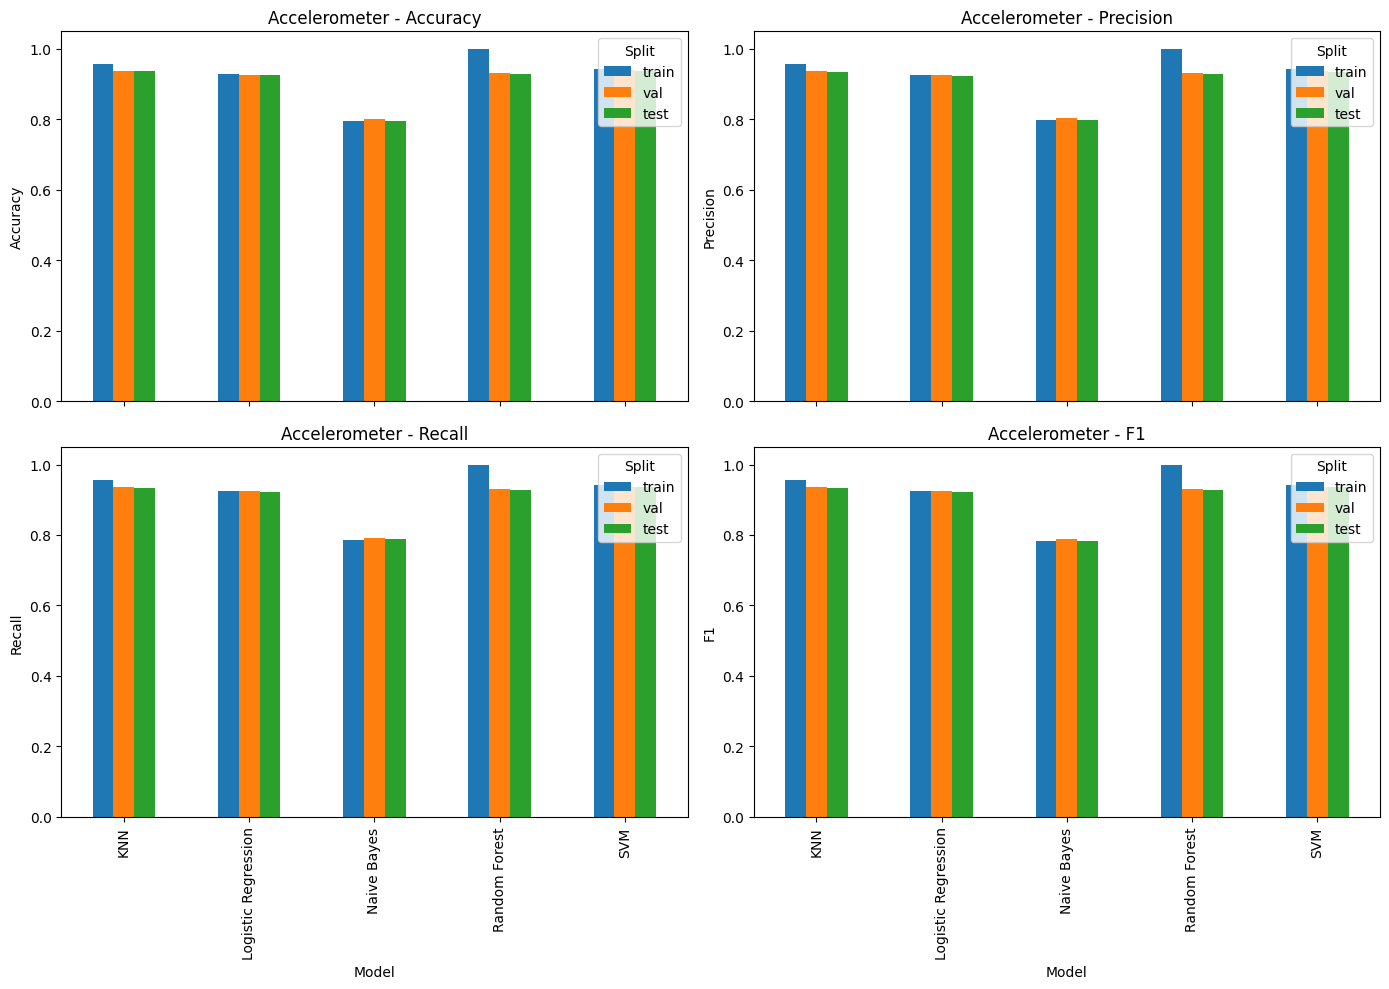

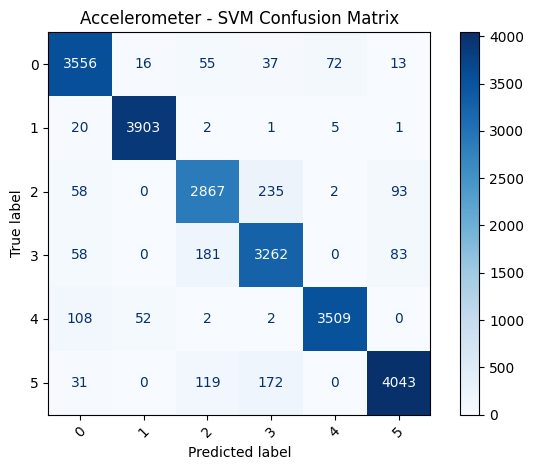

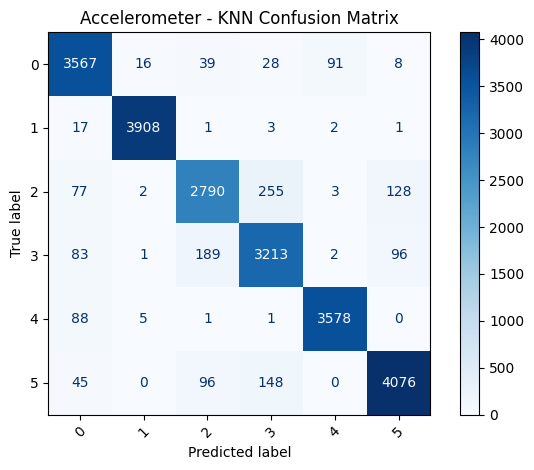

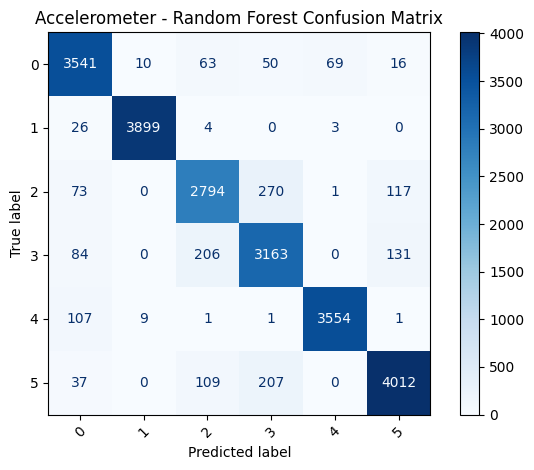

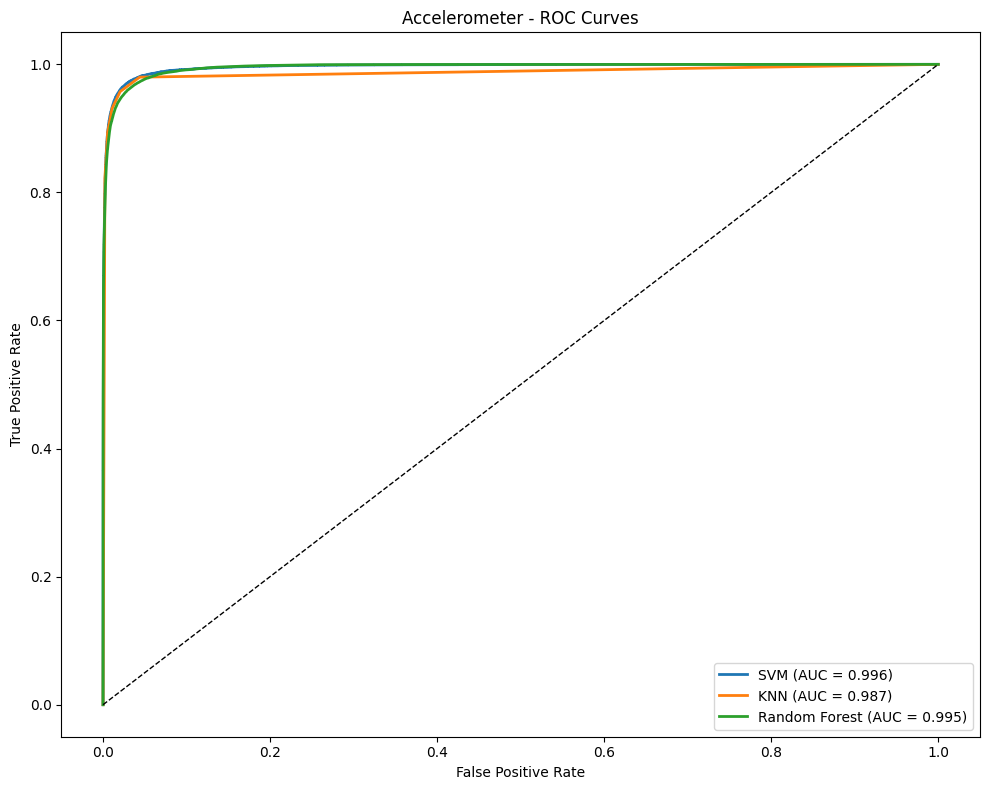

In [30]:
acc_models, acc_results = evaluate_models(
    x_acc_train_scaled, y_acc_train, x_acc_val_scaled, y_acc_val, x_acc_test_scaled, y_acc_test, 'Accelerometer'
)
display(acc_results)
plot_split_scores(acc_results, 'Accelerometer')
acc_top_models = plot_confusion_matrices(acc_models, x_acc_test_scaled, y_acc_test, 'Accelerometer')
plot_multiclass_roc(acc_models, x_acc_test_scaled, y_acc_test, 'Accelerometer')

In [7]:
### Gyroscope

Gyroscope models and metrics are evaluated with the same pipeline to compare sensor performance fairly.


=== Gyroscope: Logistic Regression ===
              precision    recall  f1-score   support

           0       0.88      0.88      0.88      3804
           1       0.68      0.83      0.75      4421
           2       0.84      0.81      0.83      3349
           3       0.87      0.89      0.88      3767
           4       0.73      0.56      0.63      4084
           5       0.91      0.92      0.92      4701

    accuracy                           0.82     24126
   macro avg       0.82      0.81      0.81     24126
weighted avg       0.82      0.82      0.81     24126


=== Gyroscope: SVM ===
              precision    recall  f1-score   support

           0       0.89      0.88      0.89      3804
           1       0.65      0.87      0.75      4421
           2       0.85      0.86      0.86      3349
           3       0.89      0.91      0.90      3767
           4       0.75      0.48      0.59      4084
           5       0.94      0.92      0.93      4701

    accuracy 

,sensor,model,split,accuracy,precision,recall,f1
0,Gyroscope,Logistic Regression,train,0.817985,0.821701,0.816855,0.816110
1,Gyroscope,Logistic Regression,val,0.822432,0.826156,0.821664,0.820678
2,Gyroscope,Logistic Regression,test,0.815717,0.819718,0.814256,0.813832
3,Gyroscope,SVM,train,0.830752,0.839258,0.831161,0.827414
4,Gyroscope,SVM,val,0.825334,0.833088,0.825515,0.821471
5,Gyroscope,SVM,test,0.821686,0.829394,0.821400,0.818174
6,Gyroscope,Random Forest,train,1.000000,1.000000,1.000000,1.000000
7,Gyroscope,Random Forest,val,0.848628,0.847941,0.848313,0.848115
8,Gyroscope,Random Forest,test,0.845851,0.845531,0.845447,0.845475
9,Gyroscope,Naive Bayes,train,0.635756,0.639218,0.621285,0.596888


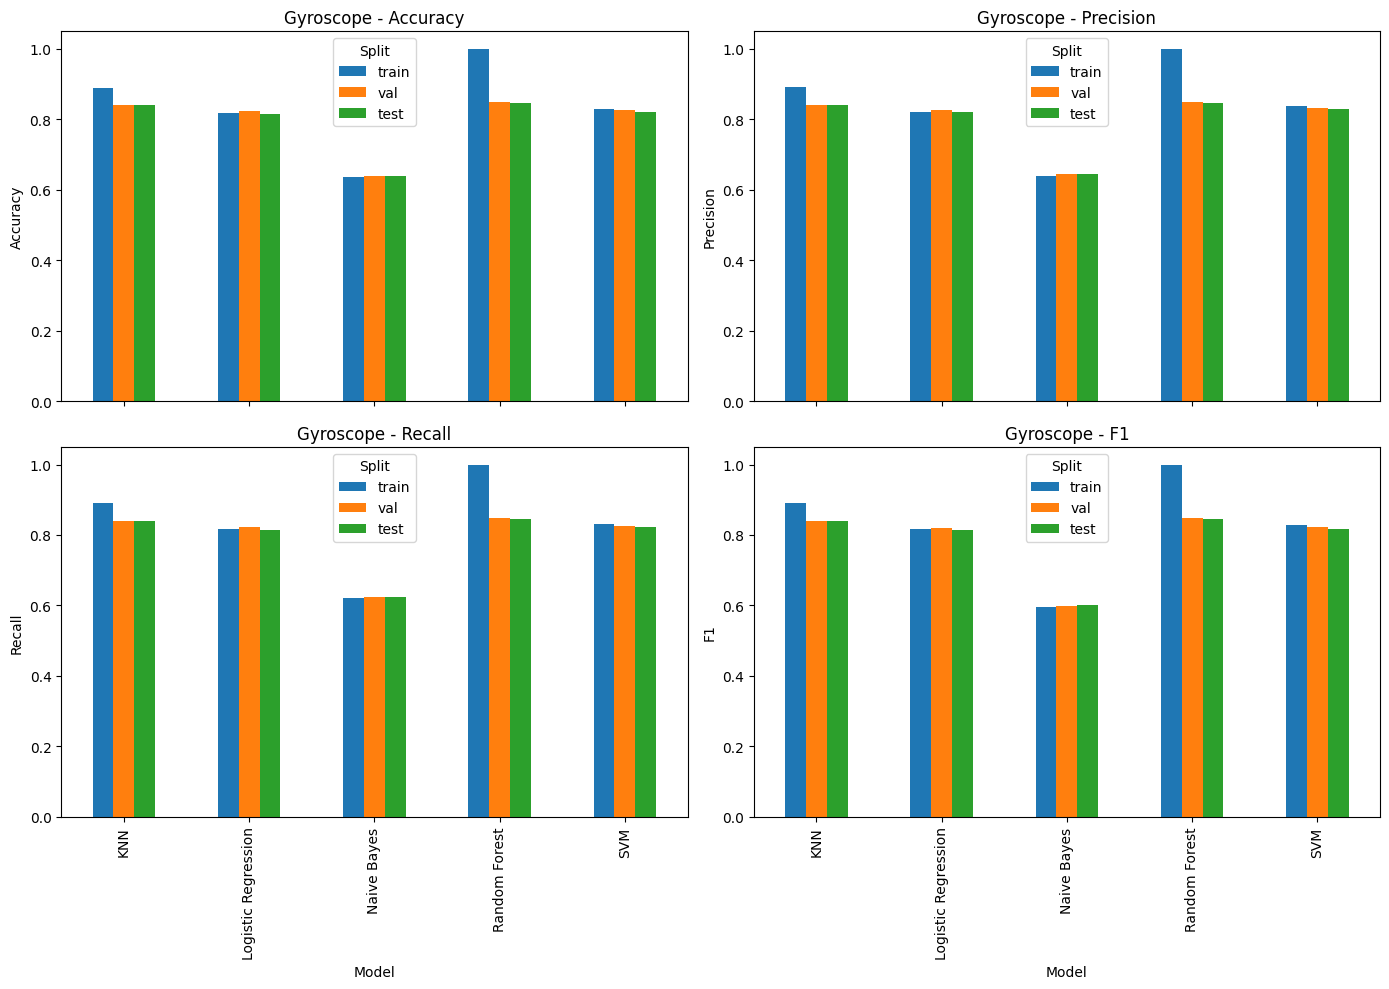

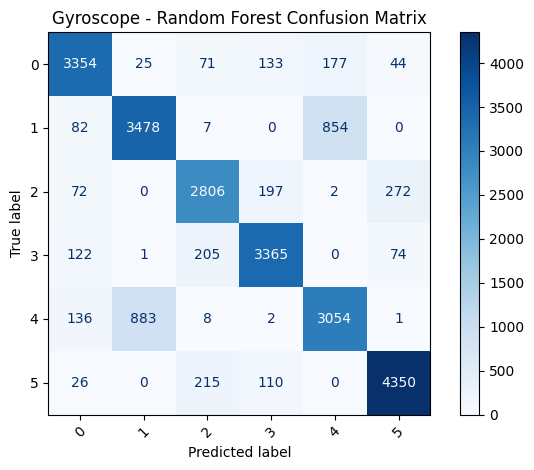

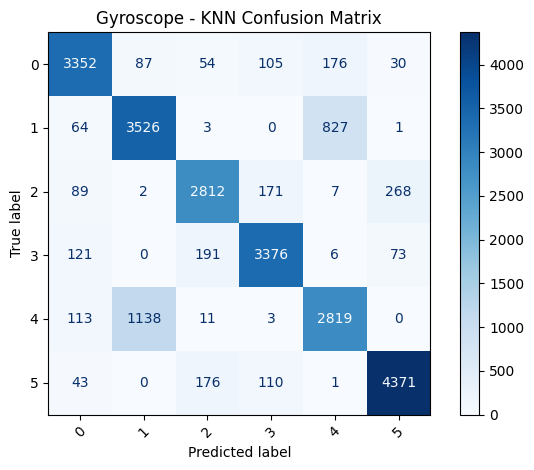

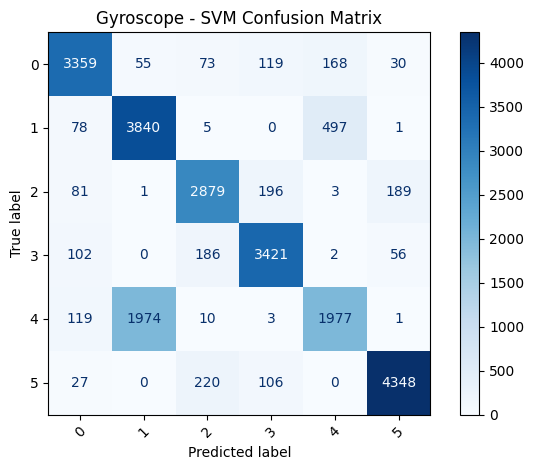

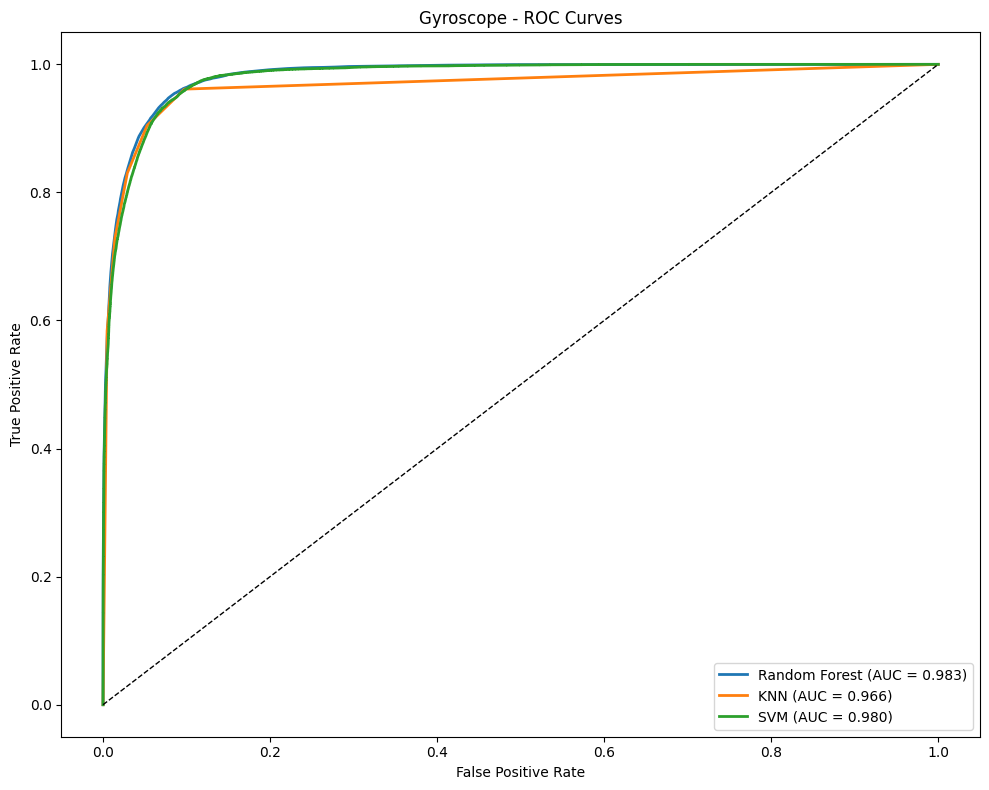

In [8]:
gyro_models, gyro_results = evaluate_models(
    x_gyro_train_scaled, y_gyro_train, x_gyro_val_scaled, y_gyro_val, x_gyro_test_scaled, y_gyro_test, 'Gyroscope'
)
display(gyro_results)
plot_split_scores(gyro_results, 'Gyroscope')
gyro_top_models = plot_confusion_matrices(gyro_models, x_gyro_test_scaled, y_gyro_test, 'Gyroscope')
plot_multiclass_roc(gyro_models, x_gyro_test_scaled, y_gyro_test, 'Gyroscope')


In [10]:
# Compare the best test F1-score across sensors
acc_best = acc_results[acc_results['split'] == 'test'].sort_values('f1', ascending=False).drop_duplicates('model')
gyro_best = gyro_results[gyro_results['split'] == 'test'].sort_values('f1', ascending=False).drop_duplicates('model')
comparison = pd.concat([acc_best.assign(sensor='Accelerometer'), gyro_best.assign(sensor='Gyroscope')])
display(comparison[['sensor', 'model', 'accuracy', 'precision', 'recall', 'f1']].sort_values(['sensor', 'f1'], ascending=[True, False]))

fig, ax = plt.subplots(figsize=(10, 5))
comparison_plot = comparison[['sensor', 'model', 'f1']].copy()
comparison_plot['label'] = comparison_plot['sensor'] + ' - ' + comparison_plot['model']
ax.bar(comparison_plot['label'], comparison_plot['f1'])
ax.set_ylabel('Macro F1-score')
ax.set_title('Best Model Comparison by Sensor')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

NameError: name 'acc_results' is not defined

In [11]:
# Save the metrics tables so they can be reused in the report
results_dir = Path('processed')
results_dir.mkdir(parents=True, exist_ok=True)
acc_results.to_csv(results_dir / 'accelerometer_model_results.csv', index=False)
gyro_results.to_csv(results_dir / 'gyroscope_model_results.csv', index=False)
print('Saved results tables to', results_dir)


NameError: name 'acc_results' is not defined

In [12]:
# Notebook conclusion: the missing part is now covered by multi-model comparison, metrics, confusion matrices, and ROC plots.

In [13]:
# Optional: show the final best model per sensor
best_acc = acc_results[acc_results['split'] == 'test'].sort_values('f1', ascending=False).iloc[0]
best_gyro = gyro_results[gyro_results['split'] == 'test'].sort_values('f1', ascending=False).iloc[0]
print('Best accelerometer model:', best_acc['model'], 'F1 =', round(best_acc['f1'], 4))
print('Best gyroscope model:', best_gyro['model'], 'F1 =', round(best_gyro['f1'], 4))

NameError: name 'acc_results' is not defined

## Watch Training (Using Existing Phone Helper Functions)

This section reuses the same training architecture already used for phone features:
- `evaluate_models(...)`
- `plot_split_scores(...)`
- `plot_confusion_matrices(...)`
- `plot_multiclass_roc(...)`

In [14]:
watch_acc_npz = np.load("watch_acc_features_full.npz", allow_pickle=True)
watch_acc_features = watch_acc_npz["features"]
watch_acc_labels = watch_acc_npz["labels"]

watch_gyro_npz = np.load("watch_gyro_features_full.npz", allow_pickle=True)
watch_gyro_features = watch_gyro_npz["features"]
watch_gyro_labels = watch_gyro_npz["labels"]

watch_label_encoder = LabelEncoder()
watch_label_encoder.fit(np.concatenate([
    np.asarray(watch_acc_labels).astype(str),
    np.asarray(watch_gyro_labels).astype(str),
]))

y_watch_acc = watch_label_encoder.transform(np.asarray(watch_acc_labels).astype(str))
y_watch_gyro = watch_label_encoder.transform(np.asarray(watch_gyro_labels).astype(str))

watch_class_names = list(watch_label_encoder.classes_)
print("Watch classes:", watch_class_names)
print("Watch acc features:", watch_acc_features.shape)
print("Watch gyro features:", watch_gyro_features.shape)

Watch classes: [np.str_('0'), np.str_('1'), np.str_('2'), np.str_('3'), np.str_('4'), np.str_('5')]
Watch acc features: (30202, 64)
Watch gyro features: (27345, 64)


In [15]:
def split_and_scale_features(X, y, random_state=42):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=random_state, stratify=y
    )
    X_train, X_val, y_train, y_val = train_test_split(
        X_train, y_train, test_size=0.125, random_state=random_state, stratify=y_train
    )

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_val_scaled = scaler.transform(X_val)
    X_test_scaled = scaler.transform(X_test)

    return X_train_scaled, X_val_scaled, X_test_scaled, y_train, y_val, y_test


=== Watch Accelerometer (helper reuse): Logistic Regression ===
              precision    recall  f1-score   support

           0       0.90      0.94      0.92      1271
           1       0.92      0.95      0.93       848
           2       0.60      0.52      0.56       974
           3       0.57      0.48      0.52       946
           4       0.89      0.89      0.89       902
           5       0.64      0.76      0.70      1100

    accuracy                           0.76      6041
   macro avg       0.75      0.76      0.75      6041
weighted avg       0.76      0.76      0.76      6041


=== Watch Accelerometer (helper reuse): SVM ===
              precision    recall  f1-score   support

           0       0.90      0.94      0.92      1271
           1       0.93      0.95      0.94       848
           2       0.61      0.57      0.59       974
           3       0.59      0.51      0.55       946
           4       0.93      0.88      0.90       902
           5      

,sensor,model,split,accuracy,precision,recall,f1
0,Watch Accelerometer (helper reuse),Logistic Regression,train,0.768921,0.763046,0.763690,0.760989
1,Watch Accelerometer (helper reuse),Logistic Regression,val,0.767958,0.762756,0.763267,0.761045
2,Watch Accelerometer (helper reuse),Logistic Regression,test,0.761298,0.755000,0.756545,0.753575
3,Watch Accelerometer (helper reuse),SVM,train,0.785383,0.782447,0.780014,0.779337
4,Watch Accelerometer (helper reuse),SVM,val,0.778219,0.774868,0.773440,0.772342
5,Watch Accelerometer (helper reuse),SVM,test,0.777024,0.773638,0.772137,0.771416
6,Watch Accelerometer (helper reuse),Random Forest,train,1.000000,1.000000,1.000000,1.000000
7,Watch Accelerometer (helper reuse),Random Forest,val,0.811652,0.811446,0.808635,0.809625
8,Watch Accelerometer (helper reuse),Random Forest,test,0.811290,0.811620,0.808459,0.809747
9,Watch Accelerometer (helper reuse),Naive Bayes,train,0.630227,0.645618,0.625142,0.593676


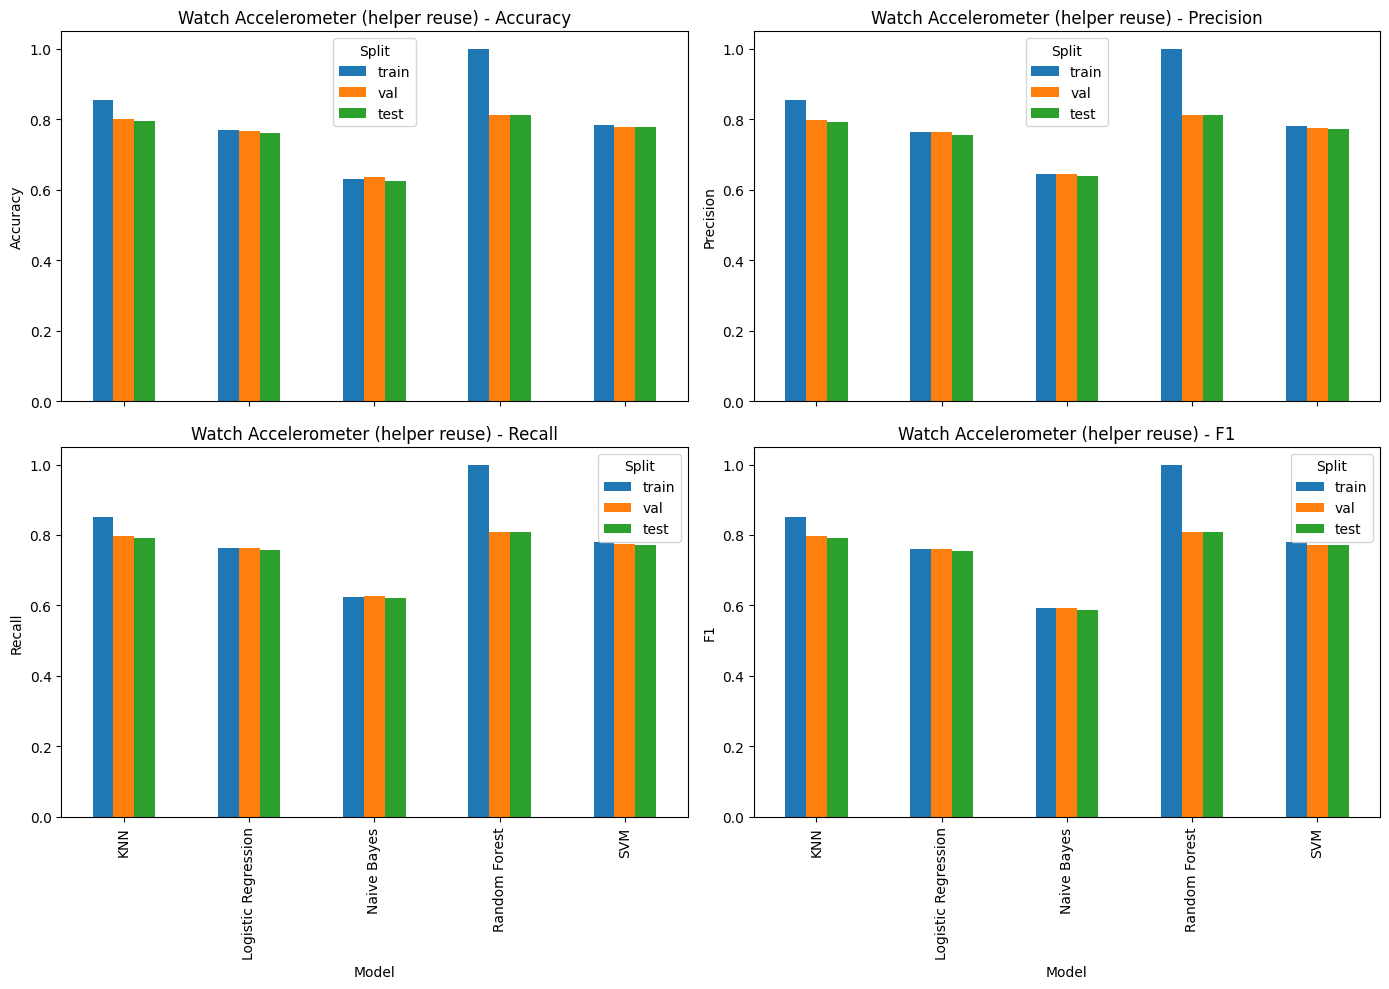

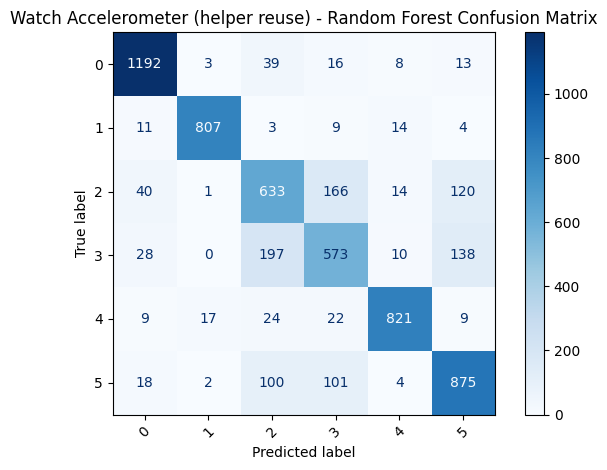

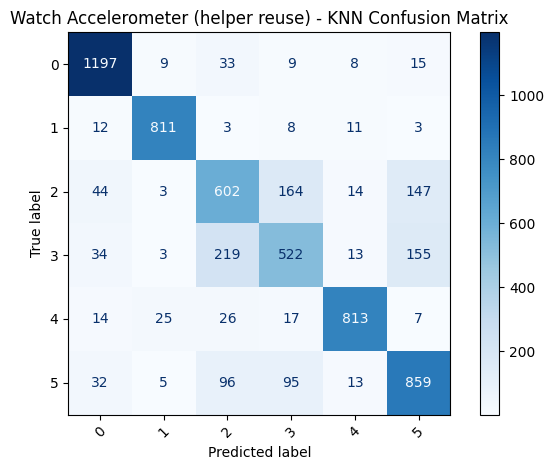

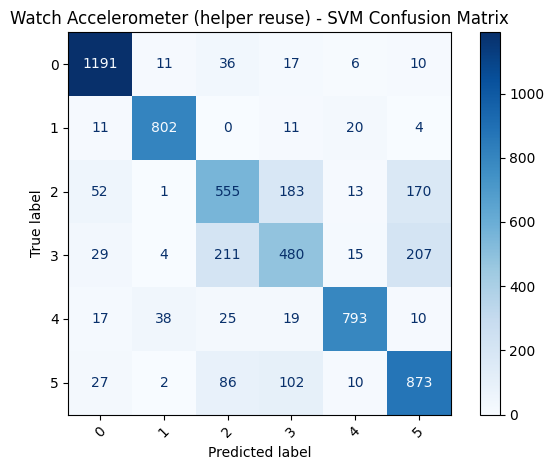

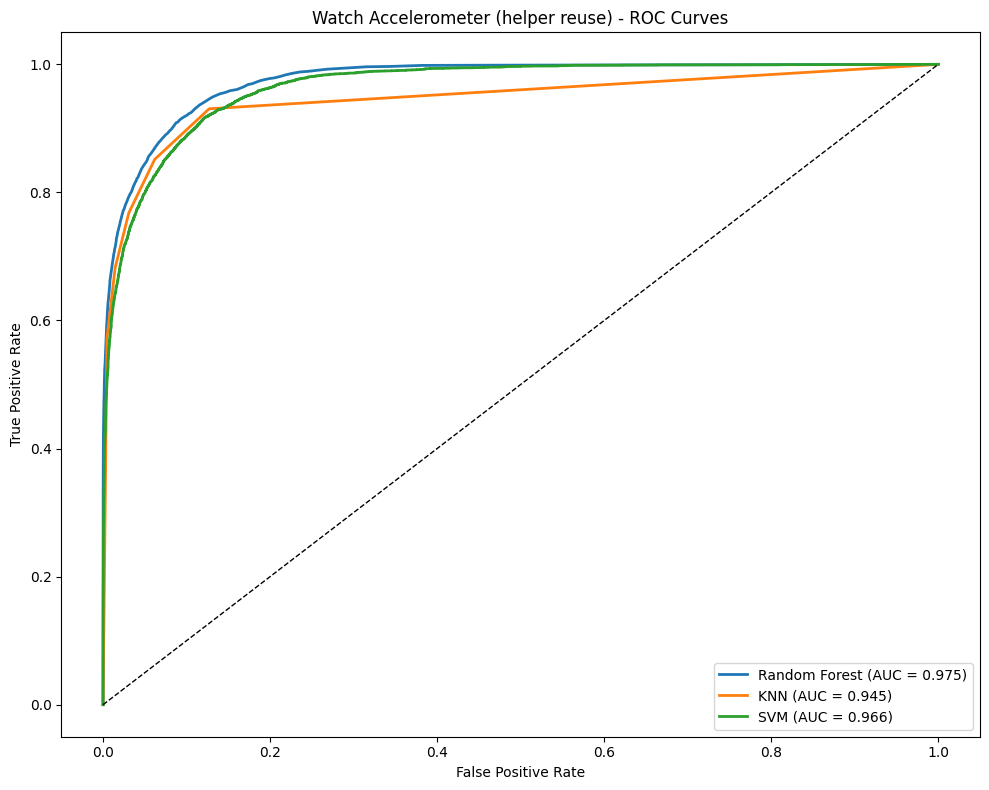


=== Watch Gyroscope (helper reuse): Logistic Regression ===
              precision    recall  f1-score   support

           0       0.80      0.88      0.84      1045
           1       0.61      0.79      0.69       839
           2       0.62      0.57      0.60       856
           3       0.64      0.53      0.58       892
           4       0.66      0.41      0.50       861
           5       0.62      0.74      0.68       976

    accuracy                           0.66      5469
   macro avg       0.66      0.65      0.65      5469
weighted avg       0.66      0.66      0.65      5469


=== Watch Gyroscope (helper reuse): SVM ===
              precision    recall  f1-score   support

           0       0.82      0.87      0.85      1045
           1       0.60      0.74      0.66       839
           2       0.64      0.64      0.64       856
           3       0.64      0.59      0.61       892
           4       0.62      0.41      0.49       861
           5       0.66   

,sensor,model,split,accuracy,precision,recall,f1
0,Watch Gyroscope (helper reuse),Logistic Regression,train,0.668304,0.661847,0.659493,0.652542
1,Watch Gyroscope (helper reuse),Logistic Regression,val,0.676051,0.672948,0.668263,0.661915
2,Watch Gyroscope (helper reuse),Logistic Regression,test,0.661913,0.657881,0.653742,0.646600
3,Watch Gyroscope (helper reuse),SVM,train,0.711718,0.704565,0.703367,0.699137
4,Watch Gyroscope (helper reuse),SVM,val,0.682633,0.676263,0.674607,0.670539
5,Watch Gyroscope (helper reuse),SVM,test,0.671055,0.663834,0.663276,0.658017
6,Watch Gyroscope (helper reuse),Random Forest,train,1.000000,1.000000,1.000000,1.000000
7,Watch Gyroscope (helper reuse),Random Forest,val,0.703473,0.701790,0.696743,0.697247
8,Watch Gyroscope (helper reuse),Random Forest,test,0.681477,0.677567,0.674026,0.674017
9,Watch Gyroscope (helper reuse),Naive Bayes,train,0.482890,0.463650,0.480123,0.449133


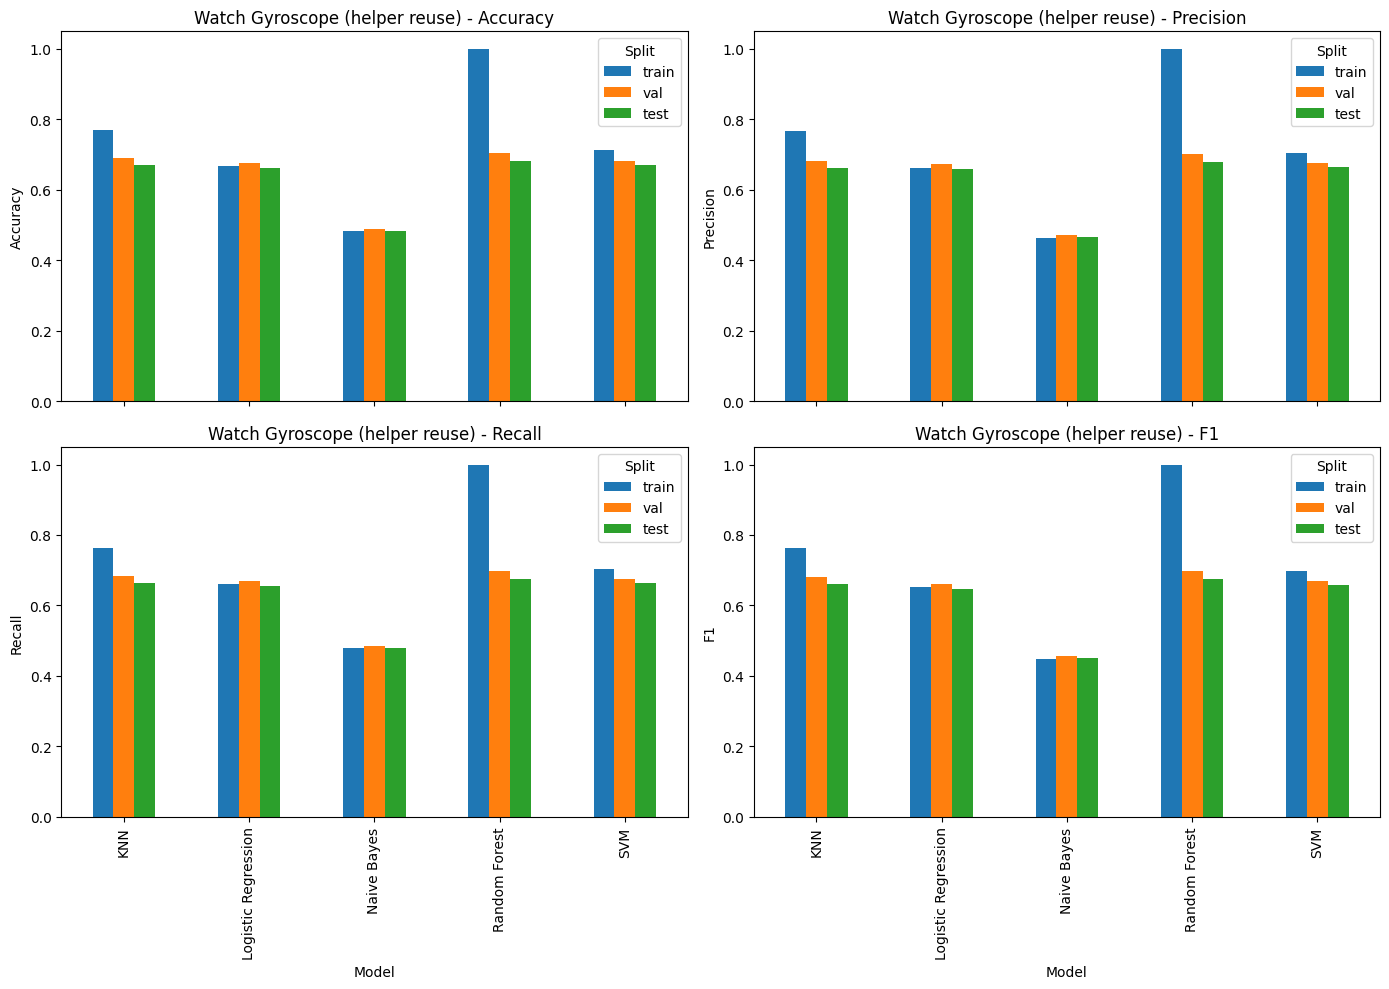

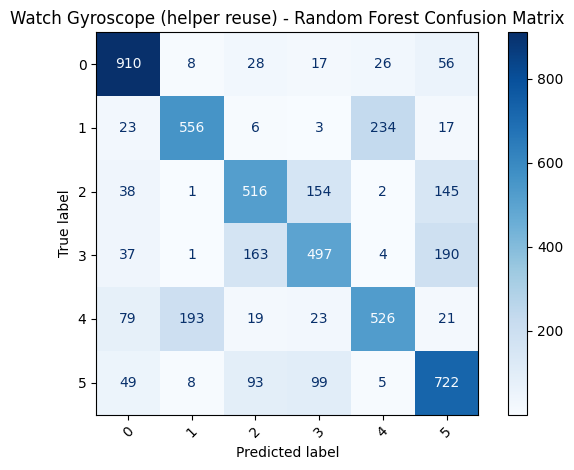

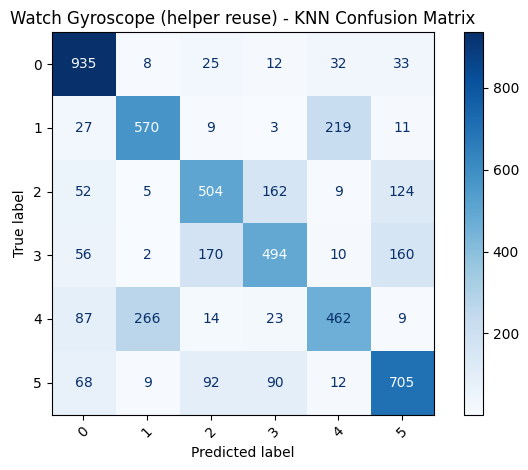

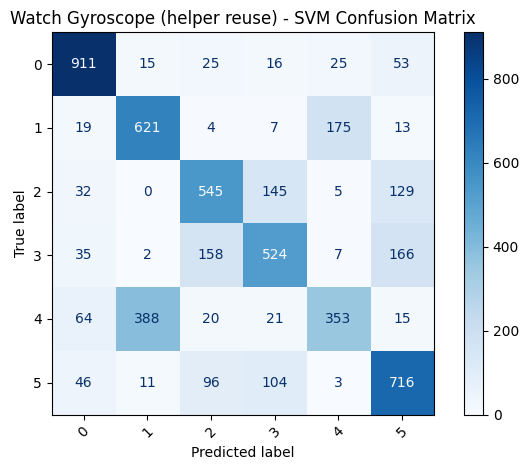

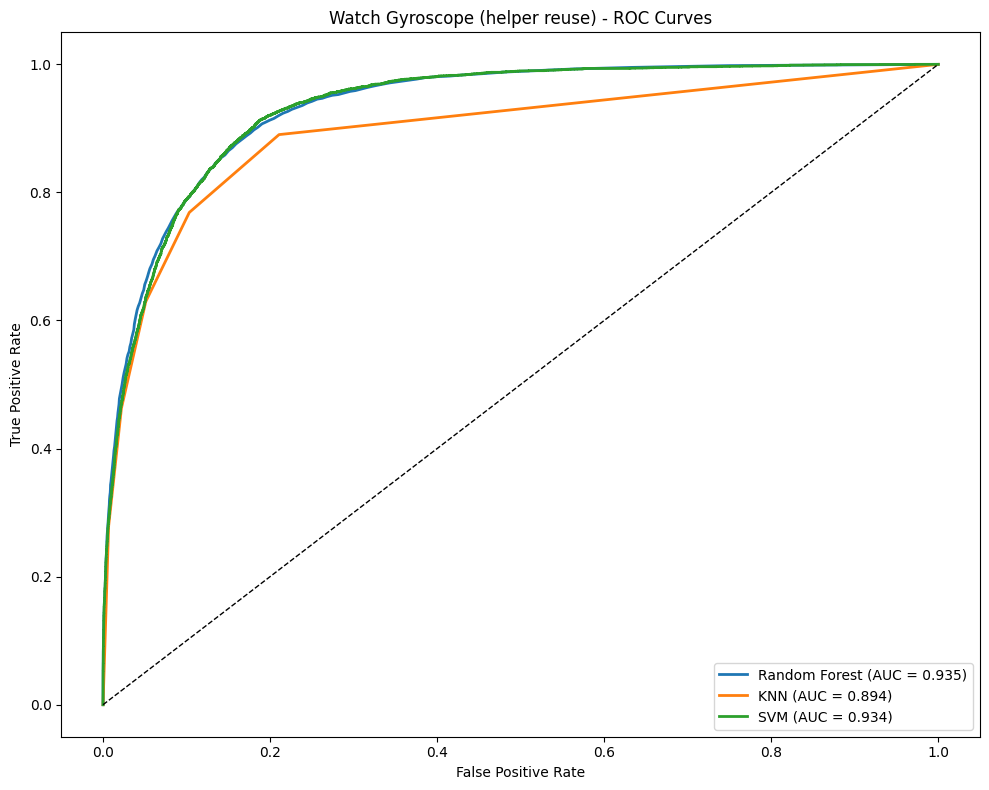

In [16]:
phone_class_names_backup = class_names
class_names = watch_class_names

# Watch accelerometer via existing helper pipeline
wacc_X_train, wacc_X_val, wacc_X_test, wacc_y_train, wacc_y_val, wacc_y_test = split_and_scale_features(
    watch_acc_features, y_watch_acc
)

watch_acc_models_v2, watch_acc_results_v2 = evaluate_models(
    wacc_X_train, wacc_y_train,
    wacc_X_val, wacc_y_val,
    wacc_X_test, wacc_y_test,
    sensor_name="Watch Accelerometer (helper reuse)"
)

display(watch_acc_results_v2)
plot_split_scores(watch_acc_results_v2, "Watch Accelerometer (helper reuse)")
plot_confusion_matrices(watch_acc_models_v2, wacc_X_test, wacc_y_test, "Watch Accelerometer (helper reuse)")
plot_multiclass_roc(watch_acc_models_v2, wacc_X_test, wacc_y_test, "Watch Accelerometer (helper reuse)")

# Watch gyroscope via existing helper pipeline
wgyro_X_train, wgyro_X_val, wgyro_X_test, wgyro_y_train, wgyro_y_val, wgyro_y_test = split_and_scale_features(
    watch_gyro_features, y_watch_gyro
)

watch_gyro_models_v2, watch_gyro_results_v2 = evaluate_models(
    wgyro_X_train, wgyro_y_train,
    wgyro_X_val, wgyro_y_val,
    wgyro_X_test, wgyro_y_test,
    sensor_name="Watch Gyroscope (helper reuse)"
)

display(watch_gyro_results_v2)
plot_split_scores(watch_gyro_results_v2, "Watch Gyroscope (helper reuse)")
plot_confusion_matrices(watch_gyro_models_v2, wgyro_X_test, wgyro_y_test, "Watch Gyroscope (helper reuse)")
plot_multiclass_roc(watch_gyro_models_v2, wgyro_X_test, wgyro_y_test, "Watch Gyroscope (helper reuse)")

class_names = phone_class_names_backup

In [17]:
results_dir = Path("processed")
results_dir.mkdir(parents=True, exist_ok=True)

watch_acc_results_v2.to_csv(results_dir / "watch_acc_model_results_helper_reuse.csv", index=False)
watch_gyro_results_v2.to_csv(results_dir / "watch_gyro_model_results_helper_reuse.csv", index=False)

print("Saved:", results_dir / "watch_acc_model_results_helper_reuse.csv")
print("Saved:", results_dir / "watch_gyro_model_results_helper_reuse.csv")

Saved: processed\watch_acc_model_results_helper_reuse.csv
Saved: processed\watch_gyro_model_results_helper_reuse.csv


## Save Best Trained Models

This final section saves the **best** trained classifier for each sensor experiment, selected by test macro F1-score.

In [18]:
import joblib

MODEL_DIR = Path('saved_models')
MODEL_DIR.mkdir(parents=True, exist_ok=True)


def save_best_model(fitted_models, results_df, sensor_label, prefix):
    test_scores = results_df[(results_df['sensor'] == sensor_label) & (results_df['split'] == 'test')].copy()
    if test_scores.empty:
        print(f'No test results found for {sensor_label}; skipping save.')
        return None

    best_row = test_scores.sort_values('f1', ascending=False).iloc[0]
    best_model_name = best_row['model']
    best_model = fitted_models[best_model_name]

    safe_name = best_model_name.lower().replace(' ', '_')
    path = MODEL_DIR / f'{prefix}_best_{safe_name}.joblib'
    joblib.dump(best_model, path)
    print(f'Saved best model for {sensor_label}: {path.resolve()}')
    return path


saved_model_paths = []

if 'acc_models' in globals() and 'acc_results' in globals():
    path = save_best_model(acc_models, acc_results, 'Accelerometer', 'phone_acc')
    if path is not None:
        saved_model_paths.append(path)

if 'gyro_models' in globals() and 'gyro_results' in globals():
    path = save_best_model(gyro_models, gyro_results, 'Gyroscope', 'phone_gyro')
    if path is not None:
        saved_model_paths.append(path)

if 'watch_acc_models_v2' in globals() and 'watch_acc_results_v2' in globals():
    path = save_best_model(watch_acc_models_v2, watch_acc_results_v2, 'Watch Accelerometer (helper reuse)', 'watch_acc')
    if path is not None:
        saved_model_paths.append(path)

if 'watch_gyro_models_v2' in globals() and 'watch_gyro_results_v2' in globals():
    path = save_best_model(watch_gyro_models_v2, watch_gyro_results_v2, 'Watch Gyroscope (helper reuse)', 'watch_gyro')
    if path is not None:
        saved_model_paths.append(path)

print('Saved model files:')
for path in saved_model_paths:
    print(path.resolve())

Saved best model for Gyroscope: C:\Users\suhur\Downloads\New folder (2)\saved_models\phone_gyro_best_random_forest.joblib
Saved best model for Watch Accelerometer (helper reuse): C:\Users\suhur\Downloads\New folder (2)\saved_models\watch_acc_best_random_forest.joblib
Saved best model for Watch Gyroscope (helper reuse): C:\Users\suhur\Downloads\New folder (2)\saved_models\watch_gyro_best_random_forest.joblib
Saved model files:
C:\Users\suhur\Downloads\New folder (2)\saved_models\phone_gyro_best_random_forest.joblib
C:\Users\suhur\Downloads\New folder (2)\saved_models\watch_acc_best_random_forest.joblib
C:\Users\suhur\Downloads\New folder (2)\saved_models\watch_gyro_best_random_forest.joblib
